# <center>Đồ án 1: Hồi quy tuyến tính</center>

# Thông tin sinh viên

- Họ và tên: Trần Trung Hiếu
- MSSV: 24122033
- Lớp: 24TNT1

# Import

In [132]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Import thư viện tại đây

# Đọc dữ liệu

In [134]:
# Doc du lieu
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Kich thuoc train:', train.shape)
print('Kich thuoc test :', test.shape)

# Thiet lap cho bo Ames
# - train.csv co cot muc tieu SalePrice
# - test.csv cung co cot SalePrice de danh gia mo hinh
TARGET_COL = 'SalePrice'
ID_COL = 'Id'

X_train_full = train.drop(columns=[TARGET_COL, ID_COL], errors='ignore').copy()
y_train_full = train[TARGET_COL].copy()
X_test = test.drop(columns=[TARGET_COL, ID_COL], errors='ignore').copy()
y_test = test[TARGET_COL].copy()

# Dong bo thu tu cot giua tap train va test
X_test = X_test.reindex(columns=X_train_full.columns)

print('So dac trung dau vao:', X_train_full.shape[1])
print('Cot muc tieu:', TARGET_COL)

Kich thuoc train: (1460, 81)
Kich thuoc test : (1459, 81)
So dac trung dau vao: 79
Cot muc tieu: SalePrice


# Cài đặt hàm

In [135]:
# Cài đặt các hàm cần thiết ở đây

*Chú thích: Cần có docstrings cho các hàm.*

# Yêu cầu 1: Phân tích khám phá dữ liệu (1 điểm)

Thực hiện EDA chủ yếu trên tập huấn luyện.
Có thể đối chiếu thống kê cơ bản giữa tập huấn luyện và tập kiểm tra, nhưng không dùng tập kiểm tra để điều chỉnh mô hình.\

### Các công việc con trong yêu cầu
- a) **Đọc dữ liệu:** kiểm tra lại số hàng hoặc cột, tên cột, kiểu đữ liệu của tập huấn luyện.
- b) **Xử lí giá trị bị thiếu:** tính tổng các giá trị null trong mỗi cột, sửa lại các cột bị hiểu nhầm là NA, ví dụ như cột PoolQC: NA có nghĩa là căn nhà không có hồ bơi.
- c) **Thống kê mô tả:** xem xét các thống kê như giá trị trung bình, độ lệch chuẩn, giá trị cực đại, phát hiện các điểm ngoại lai.
- d) **Phân tích cột SalePrice:** xem phân phối của biến SalePrice.
- e) **Vẽ đồ thị biểu diễn quan hệ:** tìm các đặc trưng ảnh hưởng nhiều nhất đến sự biến thiên của giá nhà.

In [136]:
# a) Doc du lieu tu 2 file train va test 
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

## Kiem tra lai so hang / cot / kieu du lieu
print(f"Kích thước tập huấn luyện: {train_df.shape}")
print("-" * 30)
print(train_df.info())


Kích thước tập huấn luyện: (1460, 81)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-nul


Các cột có giá trị thiếu:
MasVnrType     872
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
Electrical       1
dtype: int64


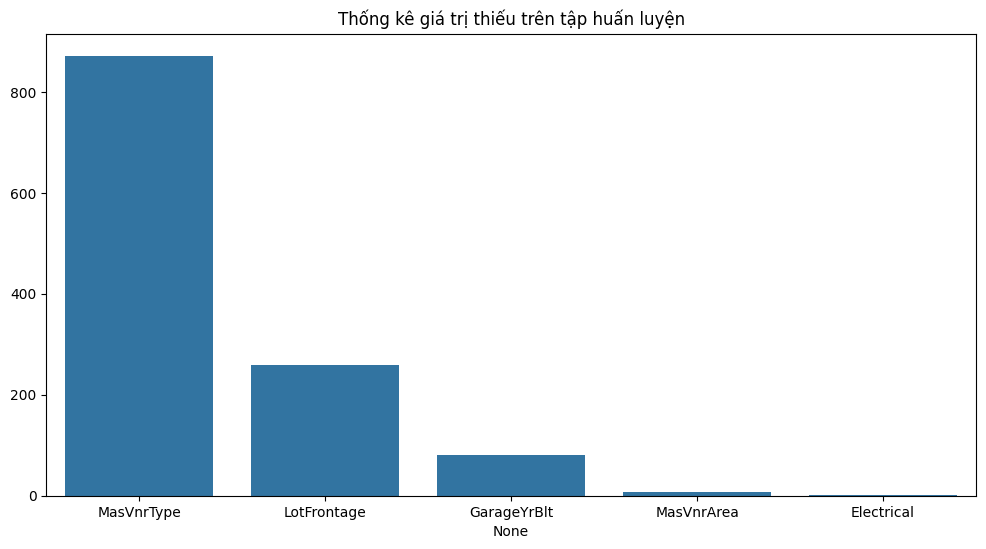

In [ ]:
# b) Xu li gia tri bi thieu
## Xu li cac cot bi hieu nham gia tri NA -> chuyen thanh "None"
none_features = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in none_features:
    train_df[col] = train_df[col].fillna('None')

missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("\nCác cột có giá trị thiếu:")
print(missing_values)

## Truc quan hoa cac cot bi thieu du lieu
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.title("Thống kê giá trị thiếu trên tập huấn luyện")
plt.show()

In [138]:
# c) Thong ke mo ta (chi tinh cac cot co kieu du lieu la so)
## Chon tat ca cac dac trung co kieu du lieu la so
all_numeric_features = train_df.select_dtypes(include=[np.number])
print("Tổng số đặc trưng số trước khi lọc:", len(all_numeric_features.columns))

## Loai bo cac cot khong co y nghia toan hoc: ID (So thu tu), MSSubClass
cols_to_drop = ['Id', 'MSSubClass']
numeric_features = all_numeric_features.drop(columns=cols_to_drop, errors='ignore')

print("Tổng số đặc trưng số sau khi lọc:", len(numeric_features.columns))
print("Danh sách các đặc trưng số:")
print(numeric_features.columns.tolist())

## Thong ke cac dac trung sau khi loc
print("\nThống kê mô tả cho các đặc trưng số:")
pd.set_option('display.max_columns', None)
print(numeric_features.describe())

Tổng số đặc trưng số trước khi lọc: 38
Tổng số đặc trưng số sau khi lọc: 36
Danh sách các đặc trưng số:
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Thống kê mô tả cho các đặc trưng số:
       LotFrontage        LotArea  OverallQual  OverallCond    YearBuilt  \
count  1201.000000    1460.000000  1460.000000  1460.000000  1460.000000   
mean     70.049958   10516.828082     6.099315     5.575342  1971.267808   
std      24.284752    9981.264932     1.382997     1.112799    30.202904   
min      21.000000    1300.000000     1.000000     1.0

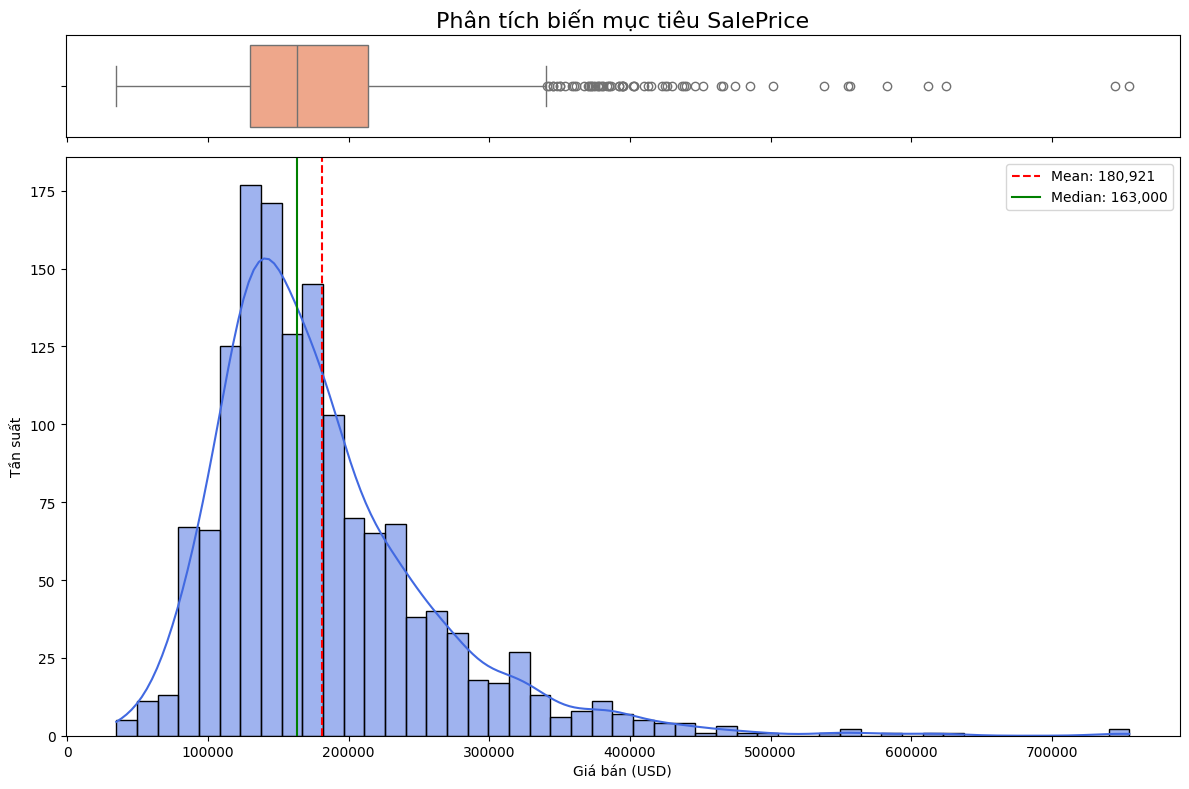

Độ lệch (Skewness): 1.88
Giá trị trung bình (Mean): 180,921.20
Giá trị trung vị (Median): 163,000.00


In [139]:
# d) Phan tich bien SalePrice
## Cac chi so thong ke co ban: mean, median, skewness
mean_price = train_df['SalePrice'].mean()
median_price = train_df['SalePrice'].median()
skewness = train_df['SalePrice'].skew()

## Ve boxplot de quan sat cac outliers
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))
sns.boxplot(x=train_df["SalePrice"], ax=ax_box, color="lightsalmon")
ax_box.set(xlabel='')
ax_box.set_title("Phân tích biến mục tiêu SalePrice", fontsize=16)

## Ve histogram va cac duong thong ke
sns.histplot(train_df['SalePrice'], kde=True, ax=ax_hist, color='royalblue')
ax_hist.axvline(mean_price, color='red', linestyle='--', label=f'Mean: {mean_price:,.0f}')
ax_hist.axvline(median_price, color='green', linestyle='-', label=f'Median: {median_price:,.0f}')

ax_hist.set_xlabel("Giá bán (USD)")
ax_hist.set_ylabel("Tần suất")
ax_hist.legend()

plt.tight_layout()
plt.show()

print(f"Độ lệch (Skewness): {skewness:.2f}")
print(f"Giá trị trung bình (Mean): {mean_price:,.2f}")
print(f"Giá trị trung vị (Median): {median_price:,.2f}")

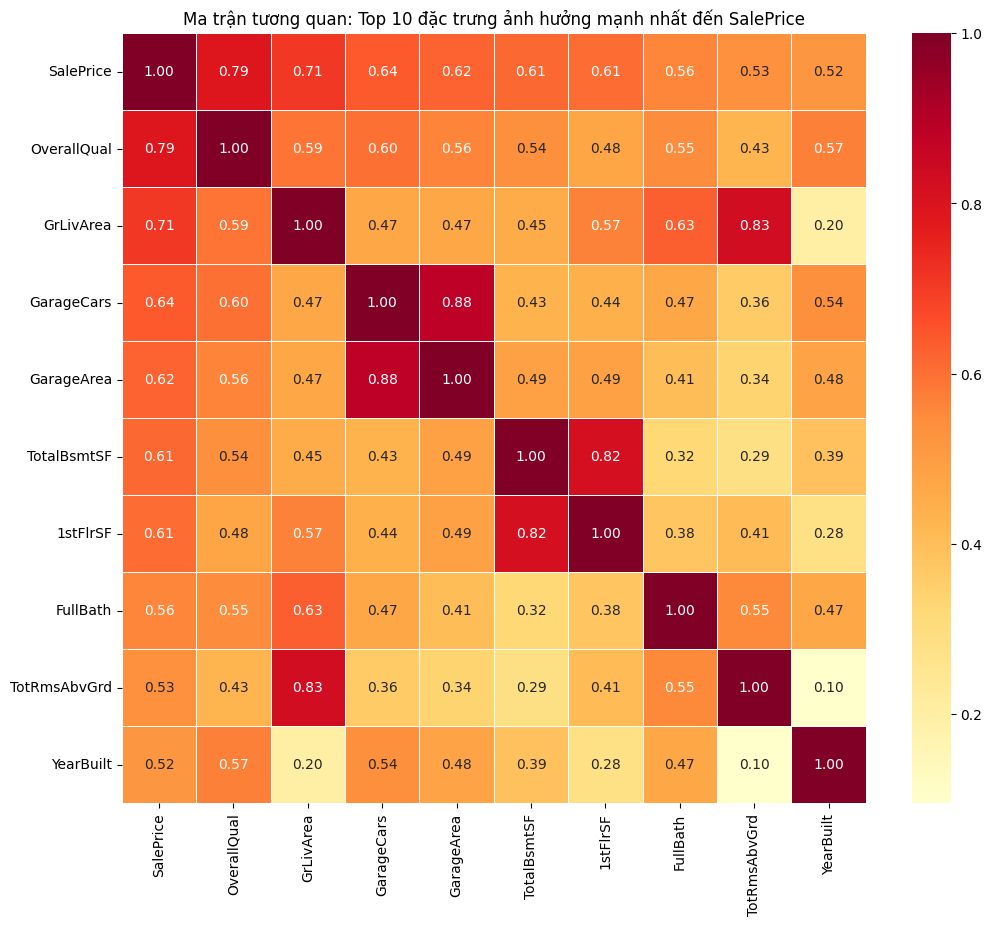

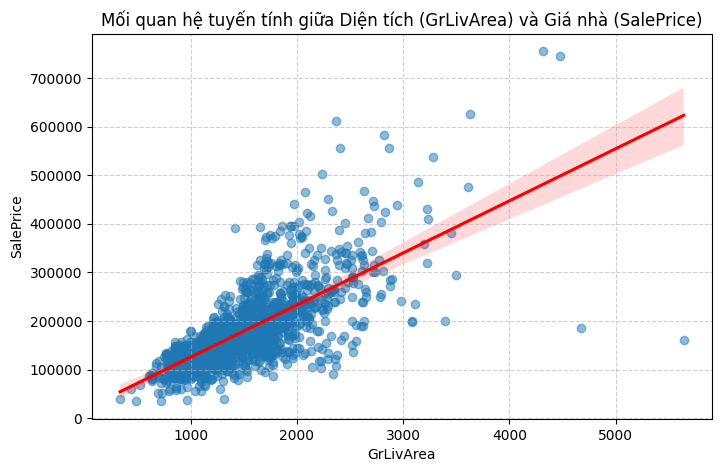

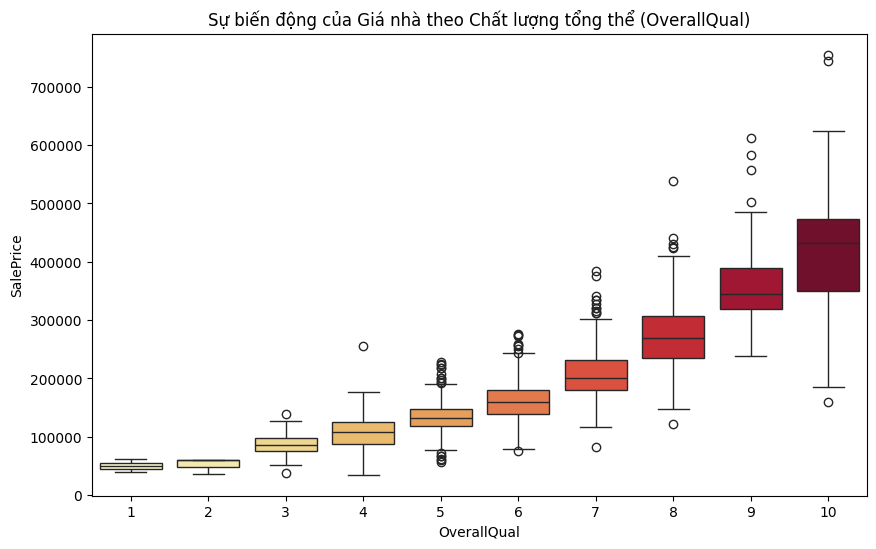

In [140]:
# e) Ve do thi bieu dien quan he

## 1. Heatmap: Top 10 dac trung tuong quan nhat voi SalePrice
plt.figure(figsize=(12, 10))
numeric_data = train.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

top_cols = corr_matrix['SalePrice'].sort_values(ascending=False).head(10).index
sns.heatmap(train[top_cols].corr(), annot=True, cmap='YlOrRd', fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan: Top 10 đặc trưng ảnh hưởng mạnh nhất đến SalePrice")
plt.show()

## 2. Scatter Plot: GrLivArea vs SalePrice
## Kiem tra moi quan he tuyen tinh giua dien tich song va gia nha
plt.figure(figsize=(8, 5))
sns.regplot(data=train, x='GrLivArea', y='SalePrice', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Mối quan hệ tuyến tính giữa Diện tích (GrLivArea) và Giá nhà (SalePrice)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 3. Boxplot: OverallQual vs SalePrice
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x='OverallQual', y='SalePrice', hue='OverallQual', palette='YlOrRd', legend=False)
plt.title("Sự biến động của Giá nhà theo Chất lượng tổng thể (OverallQual)")
plt.show()

# Yêu cầu 2a: Xây dựng mô hình sử dụng toàn bộ đặc trưng đầu vào (2 điểm)

Huấn luyện một mô hình Linear Regression sử dụng toàn bộ đặc trưng sau khi tiền xử lý phù hợp.
Sau đó báo cáo MAE của mô hình trên tập kiểm tra `test.csv`.

In [154]:
# Phan code cho yeu cau 2a

# ---------------------------------------------------------
# 1. TIEN XU LI DU LIEU
# ---------------------------------------------------------
# Tao ban sao du lieu de khong lam anh huong den du lieu goc
X_train_2a = X_train_full.copy()
X_test_2a = X_test.copy()

# Loai bo cac cot vo nghia (CHI BO ID)
cols_to_drop = ['Id']
X_train_2a = X_train_2a.drop(columns=cols_to_drop, errors='ignore')
X_test_2a = X_test_2a.drop(columns=cols_to_drop, errors='ignore')

# EP KIEU MSSubClass THANH CHUOI (STRING)
# Buoc nay bat buoc de pandas hieu day la bien phan loai (categorical) thay vi bien so
X_train_2a['MSSubClass'] = X_train_2a['MSSubClass'].astype(str)
X_test_2a['MSSubClass'] = X_test_2a['MSSubClass'].astype(str)

# Tach dac trung so va phan loai
num_cols = X_train_2a.select_dtypes(include=[np.number]).columns
cat_cols = X_train_2a.select_dtypes(include=['object']).columns

# Dien gia tri thieu
X_train_num = X_train_2a[num_cols].fillna(0)
X_test_num = X_test_2a[num_cols].fillna(0)

X_train_cat = X_train_2a[cat_cols].fillna('None')
X_test_cat = X_test_2a[cat_cols].fillna('None')

# One-Hot Encoding va Can chinh
X_train_encoded = pd.get_dummies(pd.concat([X_train_num, X_train_cat], axis=1))
X_test_encoded = pd.get_dummies(pd.concat([X_test_num, X_test_cat], axis=1))
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Ep kieu du lieu
X_train_encoded = X_train_encoded.astype(float)
X_test_encoded = X_test_encoded.astype(float)

# ---------------------------------------------------------
# 2. XAY DUNG MO HINH 
# ---------------------------------------------------------
# Them cot bias vao dau ma tran
X_train_mat = np.c_[np.ones(X_train_encoded.shape[0]), X_train_encoded.values]
X_test_mat = np.c_[np.ones(X_test_encoded.shape[0]), X_test_encoded.values]

y_train_mat = y_train_full.values.astype(float)
y_test_mat = y_test.values.astype(float)

# Tinh theta
theta_2a = np.linalg.pinv(X_train_mat.T.dot(X_train_mat)).dot(X_train_mat.T).dot(y_train_mat)


In [161]:
# Bao cao MAE cho yeu cau 2a tren tap test
print('# Lưu ý: test.csv đã có nhãn SalePrice, có thể đánh giá trực tiếp trên tập test')
# ---------------------------------------------------------
# 3. DU DOAN VA DANH GIA
# ---------------------------------------------------------
y_pred = X_test_mat.dot(theta_2a)
mae = np.mean(np.abs(y_test_mat - y_pred))

# Bao cao MAE cua mo hinh tren tap kien tra test.csv
print(f"MAE trên tập kiểm tra (Yêu cầu 2a): {mae:,.2f}")

# ---------------------------------------------------------
# 4. XUAT TOAN BO HE SO RA FILE CSV
# ---------------------------------------------------------
theta_df = pd.DataFrame({
    'Đặc trưng': features,
    'Hệ số': np.round(theta_2a, 3) 
})

# Luu toan bo he so ra file csv
theta_df.to_csv('model_2a_coefficients.csv', index=False, encoding='utf-8')
print("\nĐã lưu toàn bộ hệ số vào file 'model_2a_coefficients.csv'.")

# Lưu ý: test.csv đã có nhãn SalePrice, có thể đánh giá trực tiếp trên tập test
MAE trên tập kiểm tra (Yêu cầu 2a): 9,772.71

Đã lưu toàn bộ hệ số vào file 'model_2a_coefficients.csv'.


Công thức hồi quy cho mô hình 2a (làm tròn hệ số đến 3 chữ số thập phân).

$$\text{SalePrice} = -22513.679  \\
            + 8.063 * LotFrontage + 0.711 * LotArea + 6574.461 * OverallQual + 5835.106 * OverallCond \\
            + 331.825 * YearBuilt + 101.976 * YearRemodAdd + 21.681 * MasVnrArea + 19.066 * BsmtFinSF1 \\
            + 12.688 * BsmtFinSF2 + 1.286 * BsmtUnfSF + 20.070 * TotalBsmtSF + 5.439 * 1stFlrSF \\
            + 22.429 * 2ndFlrSF - 42.660 * LowQualFinSF + 38.822 * GrLivArea + 1572.325 * BsmtFullBath \\
            - 395.058 * BsmtHalfBath + 3857.492 * FullBath + 1673.675 * HalfBath - 3242.149 * BedroomAbvGr \\
            - 11297.414 * KitchenAbvGr + 1807.198 * TotRmsAbvGrd + 6155.401 * Fireplaces - 28.701 * GarageYrBlt \\
            + 4053.906 * GarageCars + 18.776 * GarageArea + 15.173 * WoodDeckSF + 1.165 * OpenPorchSF \\
            + 4.444 * EnclosedPorch + 34.846 * 3SsnPorch + 35.831 * ScreenPorch + 657.337 * PoolArea \\
            + 0.137 * MiscVal - 486.429 * MoSold - 491.095 * YrSold - 6420.290 * MSSubClass_{120} \\
            - 3526.741 * MSSubClass_{160} - 10051.125 * MSSubClass_{180} + 5257.730 * MSSubClass_{190} + 3343.350 * MSSubClass_{20} \\
            + 6315.364 * MSSubClass_{30} - 1267.866 * MSSubClass_{40} - 993.499 * MSSubClass_{45} + 1283.748 * MSSubClass_{50} \\
            + 7968.604 * MSSubClass_{60} + 10076.220 * MSSubClass_{70} - 13687.154 * MSSubClass_{75} - 7439.175 * MSSubClass_{80} \\
            - 10670.973 * MSSubClass_{85} - 2726.308 * MSSubClass_{90} - 26084.494 * MSZoning_{C} (all) + 8015.244 * MSZoning_{FV} \\
            - 2511.076 * MSZoning_{RH} + 677.284 * MSZoning_{RL} - 2635.078 * MSZoning_{RM} - 27538.185 * Street_{Grvl} \\
            + 5000.073 * Street_{Pave} - 6785.701 * Alley_{Grvl} - 8361.583 * Alley_{None} - 7390.817 * Alley_{Pave} \\
            - 8761.345 * LotShape_{IR1} - 3939.232 * LotShape_{IR2} - 2837.356 * LotShape_{IR3} - 7000.186 * LotShape_{Reg} \\
            - 6560.913 * LandContour_{Bnk} + 1832.643 * LandContour_{HLS} - 16796.669 * LandContour_{Low} - 1013.170 * LandContour_{Lvl} \\
            + 10755.270 * Utilities_{AllPub} - 33293.381 * Utilities_{NoSeWa} - 789.944 * LotConfig_{Corner} + 7242.008 * LotConfig_{CulDSac} \\
            - 8321.424 * LotConfig_{FR2} - 18109.922 * LotConfig_{FR3} - 2558.841 * LotConfig_{Inside} + 4134.046 * LandSlope_{Gtl} \\
            + 11889.548 * LandSlope_{Mod} - 38561.703 * LandSlope_{Sev} + 2708.123 * Neighborhood_{Blmngtn} + 11140.778 * Neighborhood_{Blueste} \\
            + 696.328 * Neighborhood_{BrDale} - 4626.117 * Neighborhood_{BrkSide} - 12567.853 * Neighborhood_{ClearCr} - 7917.342 * Neighborhood_{CollgCr} \\
            + 12915.766 * Neighborhood_{Crawfor} - 19528.306 * Neighborhood_{Edwards} - 9055.205 * Neighborhood_{Gilbert} - 10802.956 * Neighborhood_{IDOTRR} \\
            - 7036.686 * Neighborhood_{MeadowV} - 18693.003 * Neighborhood_{Mitchel} - 14929.450 * Neighborhood_{NAmes} + 16017.765 * Neighborhood_{NPkVill} \\
            - 15368.224 * Neighborhood_{NWAmes} + 27025.667 * Neighborhood_{NoRidge} + 20399.105 * Neighborhood_{NridgHt} - 12918.231 * Neighborhood_{OldTown} \\
            - 6812.978 * Neighborhood_{SWISU} - 8716.517 * Neighborhood_{Sawyer} - 646.744 * Neighborhood_{SawyerW} - 13.297 * Neighborhood_{Somerst} \\
            + 41612.539 * Neighborhood_{StoneBr} - 7825.608 * Neighborhood_{Timber} + 2404.337 * Neighborhood_{Veenker} - 8753.860 * Condition1_{Artery} \\
            - 1709.473 * Condition1_{Feedr} + 7916.906 * Condition1_{Norm} + 2074.337 * Condition1_{PosA} + 6427.500 * Condition1_{PosN} \\
            - 24157.981 * Condition1_{RRAe} + 4605.083 * Condition1_{RRAn} - 12662.936 * Condition1_{RRNe} + 3722.307 * Condition1_{RRNn} \\
            + 43541.537 * Condition2_{Artery} + 38381.781 * Condition2_{Feedr} + 32442.764 * Condition2_{Norm} + 91607.082 * Condition2_{PosA} \\
            - 195323.134 * Condition2_{PosN} - 93175.220 * Condition2_{RRAe} + 20413.783 * Condition2_{RRAn} + 39573.298 * Condition2_{RRNn} \\
            + 4994.027 * BldgType_{1Fam} - 9423.974 * BldgType_{2fmCon} - 2726.307 * BldgType_{Duplex} - 9932.236 * BldgType_{Twnhs} \\
            - 5449.632 * BldgType_{TwnhsE} - 4274.252 * HouseStyle_{1}.5Fin + 9534.142 * HouseStyle_{1}.5Unf - 1006.796 * HouseStyle_{1Story} \\
            - 12506.826 * HouseStyle_{2}.5Fin - 2926.609 * HouseStyle_{2}.5Unf - 17654.726 * HouseStyle_{2Story} + 1786.159 * HouseStyle_{SFoyer} \\
            + 4510.792 * HouseStyle_{SLvl} - 30142.497 * RoofStyle_{Flat} - 20649.107 * RoofStyle_{Gable} - 18230.863 * RoofStyle_{Gambrel} \\
            - 21043.229 * RoofStyle_{Hip} - 8882.070 * RoofStyle_{Mansard} + 76409.658 * RoofStyle_{Shed} - 531502.258 * RoofMatl_{ClyTile} \\
            + 43381.185 * RoofMatl_{CompShg} + 140593.464 * RoofMatl_{Membran} + 109013.991 * RoofMatl_{Metal} + 38396.897 * RoofMatl_{Roll} \\
            + 45218.722 * RoofMatl_{Tar}\&Grv + 34371.635 * RoofMatl_{WdShake} + 97988.250 * RoofMatl_{WdShngl} + 6606.748 * Exterior1st_{AsbShng} \\
            - 16382.638 * Exterior1st_{AsphShn} + 6535.982 * Exterior1st_{BrkComm} + 15875.778 * Exterior1st_{BrkFace} - 4975.244 * Exterior1st_{CBlock} \\
            - 5132.156 * Exterior1st_{CemntBd} - 5228.042 * Exterior1st_{HdBoard} - 11818.210 * Exterior1st_{ImStucc} + 2985.979 * Exterior1st_{MetalSd} \\
            - 6018.102 * Exterior1st_{Plywood} + 8293.543 * Exterior1st_{Stone} + 71.305 * Exterior1st_{Stucco} - 5319.380 * Exterior1st_{VinylSd} \\
            - 5964.111 * Exterior1st_{Wd} Sdng - 2069.574 * Exterior1st_{WdShing} - 4774.010 * Exterior2nd_{AsbShng} + 4974.037 * Exterior2nd_{AsphShn} \\
            - 976.827 * Exterior2nd_{Brk} Cmn - 2403.694 * Exterior2nd_{BrkFace} - 4975.244 * Exterior2nd_{CBlock} + 7498.998 * Exterior2nd_{CmentBd} \\
            + 2114.866 * Exterior2nd_{HdBoard} + 9150.021 * Exterior2nd_{ImStucc} - 1329.494 * Exterior2nd_{MetalSd} - 25487.519 * Exterior2nd_{Other} \\
            + 456.374 * Exterior2nd_{Plywood} - 16858.194 * Exterior2nd_{Stone} - 766.856 * Exterior2nd_{Stucco} + 5892.184 * Exterior2nd_{VinylSd} \\
            + 5672.204 * Exterior2nd_{Wd} Sdng - 724.959 * Exterior2nd_{Wd} Shng - 10983.336 * MasVnrType_{BrkCmn} - 6576.011 * MasVnrType_{BrkFace} \\
            - 3423.466 * MasVnrType_{None} - 1555.305 * MasVnrType_{Stone} + 7104.216 * ExterQual_{Ex} - 2239.909 * ExterQual_{Fa} \\
            - 13937.260 * ExterQual_{Gd} - 13465.176 * ExterQual_{TA} - 2890.141 * ExterCond_{Ex} - 5265.352 * ExterCond_{Fa} \\
            - 10244.603 * ExterCond_{Gd} + 2990.405 * ExterCond_{Po} - 7128.421 * ExterCond_{TA} - 1408.797 * Foundation_{BrkTil} \\
            + 2540.495 * Foundation_{CBlock} + 3516.489 * Foundation_{PConc} - 7396.875 * Foundation_{Slab} + 7207.322 * Foundation_{Stone} \\
            - 26996.753 * Foundation_{Wood} + 3610.797 * BsmtQual_{Ex} - 6912.939 * BsmtQual_{Fa} - 14012.806 * BsmtQual_{Gd} \\
            + 4885.829 * BsmtQual_{None} - 10108.991 * BsmtQual_{TA} - 24819.914 * BsmtCond_{Fa} - 23826.484 * BsmtCond_{Gd} \\
            + 4885.828 * BsmtCond_{None} + 42375.888 * BsmtCond_{Po} - 21153.439 * BsmtCond_{TA} - 3206.820 * BsmtExposure_{Av} \\
            + 10849.548 * BsmtExposure_{Gd} - 6817.208 * BsmtExposure_{Mn} - 8561.084 * BsmtExposure_{No} - 14802.564 * BsmtExposure_{None} \\
            - 6002.668 * BsmtFinType1_{ALQ} - 3038.218 * BsmtFinType1_{BLQ} - 322.230 * BsmtFinType1_{GLQ} - 9253.025 * BsmtFinType1_{LwQ} \\
            + 4885.829 * BsmtFinType1_{None} - 5855.823 * BsmtFinType1_{Rec} - 2951.981 * BsmtFinType1_{Unf} + 7753.612 * BsmtFinType2_{ALQ} \\
            - 5261.370 * BsmtFinType2_{BLQ} + 4773.697 * BsmtFinType2_{GLQ} - 5944.248 * BsmtFinType2_{LwQ} - 21778.797 * BsmtFinType2_{None} \\
            - 2079.571 * BsmtFinType2_{Rec} - 1.473 * BsmtFinType2_{Unf} - 7168.492 * Heating_{Floor} + 31.054 * Heating_{GasA} \\
            - 3293.883 * Heating_{GasW} - 8069.597 * Heating_{Grav} - 16663.568 * Heating_{OthW} + 12626.376 * Heating_{Wall} \\
            - 3514.366 * HeatingQC_{Ex} - 3638.454 * HeatingQC_{Fa} - 7240.023 * HeatingQC_{Gd} - 1511.739 * HeatingQC_{Po} \\
            - 6633.515 * HeatingQC_{TA} - 10815.811 * CentralAir_{N} - 11722.278 * CentralAir_{Y} + 3966.329 * Electrical_{FuseA} \\
            + 3348.072 * Electrical_{FuseF} - 4885.204 * Electrical_{FuseP} - 42309.911 * Electrical_{Mix} + 15509.332 * Electrical_{None} \\
            + 1833.258 * Electrical_{SBrkr} + 10952.007 * KitchenQual_{Ex} - 9031.905 * KitchenQual_{Fa} - 12596.974 * KitchenQual_{Gd} \\
            - 11861.238 * KitchenQual_{TA} - 557.332 * Functional_{Maj1} - 3140.419 * Functional_{Maj2} + 5263.000 * Functional_{Min1} \\
            + 8286.265 * Functional_{Min2} - 7006.802 * Functional_{Mod} - 42607.803 * Functional_{Sev} + 17224.956 * Functional_{Typ} \\
            - 7344.245 * FireplaceQu_{Ex} - 9502.925 * FireplaceQu_{Fa} - 5642.354 * FireplaceQu_{Gd} + 318.031 * FireplaceQu_{None} \\
            + 4127.745 * FireplaceQu_{Po} - 4494.371 * FireplaceQu_{TA} - 20178.831 * GarageType_{2Types} - 568.552 * GarageType_{Attchd} \\
            + 3432.576 * GarageType_{Basment} - 605.584 * GarageType_{BuiltIn} + 5256.170 * GarageType_{CarPort} + 2599.906 * GarageType_{Detchd} \\
            - 12473.781 * GarageType_{None} - 2519.246 * GarageFinish_{Fin} - 12473.780 * GarageFinish_{None} - 4726.386 * GarageFinish_{RFn} \\
            - 2818.696 * GarageFinish_{Unf} + 104866.571 * GarageQual_{Ex} - 28380.491 * GarageQual_{Fa} - 24567.615 * GarageQual_{Gd} \\
            - 12473.781 * GarageQual_{None} - 39850.791 * GarageQual_{Po} - 22132.007 * GarageQual_{TA} - 99107.878 * GarageCond_{Ex} \\
            + 19877.064 * GarageCond_{Fa} + 22142.440 * GarageCond_{Gd} - 12473.781 * GarageCond_{None} + 24264.197 * GarageCond_{Po} \\
            + 22759.832 * GarageCond_{TA} - 6094.157 * PavedDrive_{N} - 9826.090 * PavedDrive_{P} - 6617.861 * PavedDrive_{Y} \\
            + 12841.810 * PoolQC_{Ex} - 152413.113 * PoolQC_{Fa} - 123577.893 * PoolQC_{Gd} + 240611.086 * PoolQC_{None} \\
            - 10638.804 * Fence_{GdPrv} - 2444.082 * Fence_{GdWo} - 965.273 * Fence_{MnPrv} - 6761.129 * Fence_{MnWw} \\
            - 1728.830 * Fence_{None} - 14835.697 * MiscFeature_{Gar2} - 13449.858 * MiscFeature_{None} + 4994.335 * MiscFeature_{Othr} \\
            - 11138.853 * MiscFeature_{Shed} + 11891.981 * MiscFeature_{TenC} - 12372.785 * SaleType_{COD} + 3115.062 * SaleType_{CWD} \\
            + 12798.396 * SaleType_{Con} + 3681.960 * SaleType_{ConLD} - 8896.450 * SaleType_{ConLI} - 10695.479 * SaleType_{ConLw} \\
            + 8008.159 * SaleType_{New} - 5307.202 * SaleType_{Oth} - 12869.768 * SaleType_{WD} - 6733.405 * SaleCondition_{Abnorml} \\
            + 2939.844 * SaleCondition_{AdjLand} - 6946.777 * SaleCondition_{Alloca} - 5656.828 * SaleCondition_{Family} + 50.010 * SaleCondition_{Normal} \\
            - 6190.968 * SaleCondition_{Partial}$$

# Yêu cầu 2b: Xây dựng mô hình với một đặc trưng và tìm mô hình tốt nhất (2 điểm)

Huấn luyện một mô hình cho từng đặc trưng và so sánh bằng MAE trung bình theo k-fold cross-validation trên tập huấn luyện.
Sau khi chọn được đặc trưng tốt nhất, huấn luyện lại mô hình trên toàn bộ tập huấn luyện và báo cáo MAE trên tập kiểm tra `test.csv`.

Lưu ý: Chỉ xáo trộn dữ liệu một lần trước cross-validation và giữ cùng chính sách chia cho mọi đặc trưng ứng viên. Việc chọn đặc trưng phải dựa trên tập huấn luyện.

In [164]:
# Phan code cho Yeu cau 2b
# 1) Huan luyen cac mo hinh voi tung dac trung don le
# 2) Tinh MAE trung binh theo CV cho moi dac trung
# 3) Chon dac trung co MAE nho nhat
# ---------------------------------------------------------
# 1. CHUAN BI 5 DAC TRUNG TOT NHAT VA DU LIEU
# ---------------------------------------------------------
# Chon ra 5 dac trung tot nhat tu cau 1 (tu suy dien tu ma tran tuong quan/Heatmap)
top_5_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', '1stFlrSF']

# ---------------------------------------------------------
# 2. CAI DAT K-FOLD CROSS-VALIDATION
# ---------------------------------------------------------
k = 5
n_samples = len(X_train_full)

# Chi xao tron du lieu mot lan va giu cung mot thiet lap chia cho moi dac trung ung vien 
np.random.seed(42) # Giu co dinh seed de ket qua on dinh qua cac lan chay
shuffled_indices = np.random.permutation(n_samples)

# Chia cac chi so (indices) thanh k phan
fold_sizes = np.full(k, n_samples // k)
fold_sizes[:n_samples % k] += 1
current_idx = 0
folds = []
for fold_size in fold_sizes:
    start, stop = current_idx, current_idx + fold_size
    folds.append(shuffled_indices[start:stop])
    current_idx = stop

# ---------------------------------------------------------
# 3. HUAN LUYEN VA DANH GIA TUNG DAC TRUNG 
# ---------------------------------------------------------
cv_results = {}

# Xay dung mot mo hinh cho tung dac trung dau vao rieng le
for feature in top_5_features:
    # Lay du lieu cua 1 dac trung, dien 0 neu co gia tri thieu, ep kieu float
    X_f = X_train_full[[feature]].fillna(0).values.astype(float)
    y_f = y_train_full.values.astype(float)
    
    fold_maes = []
    
    # Dung k-fold cross-validation tren tap huan luyen de chon ra dac trung tot nhat
    for i in range(k):
        # Tap validation la fold hien tai
        val_idx = folds[i]
        # Tap train la cac fold con lai
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])
        
        X_tr, y_tr = X_f[train_idx], y_f[train_idx]
        X_val, y_val = X_f[val_idx], y_f[val_idx]
        
        # Them cot Bias (toan so 1) vao dau ma tran
        X_tr_mat = np.c_[np.ones(len(X_tr)), X_tr]
        X_val_mat = np.c_[np.ones(len(X_val)), X_val]
        
        # Huan luyen mo hinh bang Normal Equation
        theta = np.linalg.pinv(X_tr_mat.T.dot(X_tr_mat)).dot(X_tr_mat.T).dot(y_tr)
        
        # Du doan va tinh MAE tren tap validation
        y_pred = X_val_mat.dot(theta)
        fold_maes.append(np.mean(np.abs(y_val - y_pred)))
    
    # Luu MAE trung binh tu cross-validation cho tung dac trung
    cv_results[feature] = np.mean(fold_maes)

print("Kết quả K-Fold Cross-Validation (MAE trung bình):")
for feature, mae_val in cv_results.items():
    print(f"- {feature}: {mae_val:,.2f}")

# ---------------------------------------------------------
# 4. CHON DAC TRUNG TOT NHAT VA KIEM TRA TREN TAP TEST
# ---------------------------------------------------------
# Tim dac trung co MAE nho nhat tren tap huan luyen
best_feature = min(cv_results, key=cv_results.get)
print(f"\n=> Đặc trưng tốt nhất được chọn là: '{best_feature}'")

Kết quả K-Fold Cross-Validation (MAE trung bình):
- OverallQual: 33,814.43
- GrLivArea: 37,797.67
- TotalBsmtSF: 46,523.12
- GarageCars: 42,630.25
- 1stFlrSF: 46,462.11

=> Đặc trưng tốt nhất được chọn là: 'OverallQual'


In [165]:
# Huấn luyện lại mô hình best_feature_model với đặc trưng tốt nhất trên toàn bộ tập huấn luyện
X_train_best = np.c_[np.ones(len(X_train_full)), X_train_full[[best_feature]].fillna(0).values.astype(float)]
y_train_full_mat = y_train_full.values.astype(float)

theta_best = np.linalg.pinv(X_train_best.T.dot(X_train_best)).dot(X_train_best.T).dot(y_train_full_mat)

In [167]:
# Danh gia MAE cho best_feature_model tren tap test
print('# Sau khi chon dac trung tot nhat bang CV tren train, bao cao MAE tren test.csv')
X_test_best = np.c_[np.ones(len(X_test)), X_test[[best_feature]].fillna(0).values.astype(float)]
y_test_mat = y_test.values.astype(float)

y_pred_best = X_test_best.dot(theta_best)
test_mae_best = np.mean(np.abs(y_test_mat - y_pred_best))

print(f"\nMAE trên tập test (test.csv) của mô hình tốt nhất: {test_mae_best:,.2f}")

# Sau khi chon dac trung tot nhat bang CV tren train, bao cao MAE tren test.csv

MAE trên tập test (test.csv) của mô hình tốt nhất: 30,903.31


Công thức hồi quy cho mô hình 2b (đặc trưng tốt nhất, làm tròn đến 3 chữ số thập phân).

$$\text{SalePrice} = -96206.080 + 45435.803 * OverallQual$$

# Yêu cầu 2c: Tự thiết kế các mô hình đặc trưng và tìm mô hình tốt nhất (2 điểm)

Thiết kế ít nhất 3 phương án đặc trưng/mô hình khác nhau.
So sánh các phương án bằng k-fold cross-validation trên tập huấn luyện, sau đó huấn luyện lại mô hình tốt nhất trên toàn bộ tập huấn luyện và báo cáo MAE trên tập kiểm tra `test.csv`.

In [168]:
# Trinh bay toan bo code dung de thiet ke cac phuong an dac trung/mo hinh

# Phuong an 1: Bien doi Logarit cac bien dien tich (Giam anh huong cua outlier)
def transform_pa1(df):
    X_new = pd.DataFrame()
    X_new['OverallQual'] = df['OverallQual']
    X_new['Log_GrLivArea'] = np.log1p(df['GrLivArea'])
    X_new['Log_LotArea'] = np.log1p(df['LotArea'])
    X_new['Log_TotalBsmtSF'] = np.log1p(df['TotalBsmtSF'])
    X_new['GarageCars'] = df['GarageCars']
    return X_new.fillna(0).values.astype(float)

# Phuong an 2: Tong hop dac trung (Khai thac kien thuc thuc te de giam chieu du lieu)
def transform_pa2(df):
    X_new = pd.DataFrame()
    X_new['Total_Home_Qual'] = df['OverallQual'] + df['OverallCond']
    X_new['Total_Square_Feet'] = df['GrLivArea'] + df['TotalBsmtSF']
    X_new['Total_Bathrooms'] = df['FullBath'] + df['BsmtFullBath'] + 0.5 * (df['HalfBath'] + df['BsmtHalfBath'])
    X_new['House_Age'] = df['YrSold'] - df['YearBuilt']
    return X_new.fillna(0).values.astype(float)

# Phuong an 3: Tuong tac va Da thuc (Khai thac quan he phi tuyen)
def transform_pa3(df):
    X_new = pd.DataFrame()
    X_new['OverallQual'] = df['OverallQual']
    X_new['GrLivArea'] = df['GrLivArea']
    X_new['Qual_x_Area'] = df['OverallQual'] * df['GrLivArea'] # Tuong tac
    X_new['Qual_sq'] = df['OverallQual'] ** 2                  # Da thuc bac 2
    X_new['TotalBsmtSF'] = df['TotalBsmtSF']
    return X_new.fillna(0).values.astype(float)

Lưu ý: Chỉ xáo trộn dữ liệu một lần và đánh giá toàn bộ $m$ mô hình theo cùng thiết lập cross-validation.

In [169]:
# Phan code cho Yeu cau 2c
# 1) Dinh nghia m >= 3 phuong an dac trung/mo hinh
strategies = {
    'Phương án 1 (Biến đổi Logarit)': transform_pa1,
    'Phương án 2 (Tổng hợp đặc trưng)': transform_pa2,
    'Phương án 3 (Tương tác & Đa thức)': transform_pa3
}

# 2) Danh gia tung phuong an bang k-fold CV
cv_results_2c = {}
y_f = y_train_full.values.astype(float)

print("--- KẾT QUẢ ĐÁNH GIÁ 3 PHƯƠNG ÁN (K-FOLD CV) ---")
for strategy_name, transform_func in strategies.items():
    X_f = transform_func(X_train_full)
    fold_maes = []
    
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i])
        
        X_tr, y_tr = X_f[train_idx], y_f[train_idx]
        X_val, y_val = X_f[val_idx], y_f[val_idx]
        
        X_tr_mat = np.c_[np.ones(len(X_tr)), X_tr]
        X_val_mat = np.c_[np.ones(len(X_val)), X_val]
        
        theta = np.linalg.pinv(X_tr_mat.T.dot(X_tr_mat)).dot(X_tr_mat.T).dot(y_tr)
        
        y_pred = X_val_mat.dot(theta)
        fold_maes.append(np.mean(np.abs(y_val - y_pred)))
    
    avg_mae = np.mean(fold_maes)
    cv_results_2c[strategy_name] = avg_mae
    print(f"- {strategy_name}: MAE = {avg_mae:,.2f}")

# 3) Chon phuong an co MAE trung binh thap nhat
best_strategy_name = min(cv_results_2c, key=cv_results_2c.get)
best_transform_func = strategies[best_strategy_name]
print(f"\n=> Phương án tốt nhất: '{best_strategy_name}' với MAE CV = {cv_results_2c[best_strategy_name]:,.2f}")

--- KẾT QUẢ ĐÁNH GIÁ 3 PHƯƠNG ÁN (K-FOLD CV) ---
- Phương án 1 (Biến đổi Logarit): MAE = 26,937.96
- Phương án 2 (Tổng hợp đặc trưng): MAE = 24,605.68
- Phương án 3 (Tương tác & Đa thức): MAE = 24,711.45

=> Phương án tốt nhất: 'Phương án 2 (Tổng hợp đặc trưng)' với MAE CV = 24,605.68


In [170]:
# Huan luyen lai my_best_model tren toan bo tap huan luyen

print("\nĐang huấn luyện my_best_model trên toàn bộ tập huấn luyện...")

# Bien doi du lieu theo phuong an tot nhat
X_train_best_2c = best_transform_func(X_train_full)

# Them cot Bias vao dau ma tran
X_train_best_mat_2c = np.c_[np.ones(len(X_train_best_2c)), X_train_best_2c]

# my_best_model chinh la mang he so theta (trong so) toi uu
my_best_model = np.linalg.pinv(X_train_best_mat_2c.T.dot(X_train_best_mat_2c)).dot(X_train_best_mat_2c.T).dot(y_f)

print("Huấn luyện hoàn tất!")


Đang huấn luyện my_best_model trên toàn bộ tập huấn luyện...
Huấn luyện hoàn tất!


In [173]:
# Danh gia MAE cho my_best_model tren tap validation
print('# Co the so sanh MAE validation voi MAE CV cua phuong an duoc chon')

# Ap dung dung ham bien doi do len tap validation (X_test)
X_val_best_2c = best_transform_func(X_test)

# Them cot Bias cho tap validation
X_val_best_mat_2c = np.c_[np.ones(len(X_val_best_2c)), X_val_best_2c]
y_val_mat_2c = y_test.values.astype(float)

# Du doan va Tinh MAE
y_pred_val_2c = X_val_best_mat_2c.dot(my_best_model)
mae_val_2c = np.mean(np.abs(y_val_mat_2c - y_pred_val_2c))

# In so sanh
print(f"\n--- SO SÁNH MAE ĐÁNH GIÁ ---")
print(f"MAE CV (trên tập huấn luyện): {cv_results_2c[best_strategy_name]:,.2f}")
print(f"MAE Validation (trên tập test): {mae_val_2c:,.2f}")

# Co the so sanh MAE validation voi MAE CV cua phuong an duoc chon

--- SO SÁNH MAE ĐÁNH GIÁ ---
MAE CV (trên tập huấn luyện): 24,605.68
MAE Validation (trên tập test): 21,621.00


Lưu ý: Chỉ xáo trộn dữ liệu một lần và đánh giá toàn bộ $m$ mô hình theo cùng thiết lập cross-validation trên tập huấn luyện. Không dùng tập kiểm tra để chọn mô hình.trên tập huấn luyện. Không dùng tập kiểm tra để chọn mô hình.
* **Giải thích các đặc trưng tổng hợp mới:**
  * **Total_Home_Qual (Tổng điểm chất lượng):** Bằng OverallQual + OverallCond. Đại diện cho chất lượng toàn diện của căn nhà.
  * **Total_Square_Feet (Tổng diện tích sử dụng):** Bằng GrLivArea + TotalBsmtSF. Đo lường tổng độ rộng rãi không gian sinh hoạt (cả trên mặt đất và tầng hầm).
  * **Total_Bathrooms (Tổng số phòng tắm):** Quy đổi bằng tổng các phòng tắm đầy đủ cộng với một nửa ($0.5$) cho các phòng tắm nhỏ (HalfBath). Thước đo trực quan cho mức độ tiện nghi.
  * **House_Age (Tuổi đời căn nhà):** Bằng YrSold - YearBuilt. Mô tả độ cũ của bất động sản tính đến thời điểm giao dịch.
* **Công thức hồi quy cụ thể sau khi huấn luyện:**

$$
\begin{aligned}
\text{SalePrice} &= -100819.781 \\
&\quad + 13056.402 \cdot \text{Total\_Home\_Qual} \\
&\quad + 48.875 \cdot \text{Total\_Square\_Feet} \\
&\quad + 11663.461 \cdot \text{Total\_Bathrooms} \\
&\quad - 608.016 \cdot \text{House\_Age}
\end{aligned}
$$
*(Lưu ý: Hệ số của House_Age mang giá trị âm là hoàn toàn hợp lý với thực tế, vì nhà càng cũ thì giá trị càng giảm).*